In [ ]:
# Day 14 title:
# Day14_Linear_Interpolation_Missing_Ball_Detections_NaN_Handling_and_Small_Object_Detection_Limits

In [1]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 5.0 MB/s eta 0:00:00


In [11]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image as PILImage
from ultralytics import YOLO
import pandas as pd
model = YOLO('yolov8n.pt')
NaN = np.nan

In [4]:
cap = cv2.VideoCapture("/content/football_clip.mp4")
cap.get(cv2.CAP_PROP_FPS)# — frames per second
cap.get(cv2.CAP_PROP_FRAME_COUNT) #— total number of frames

print(cap.get(cv2.CAP_PROP_FPS))
print(cap.get(cv2.CAP_PROP_FRAME_COUNT))

frame_count = 0
saved_frame = []
ret = True
while ret:
  ret,frame = cap.read()
  if frame_count % 10 ==0:
    saved_frame.append(frame)
  frame_count+=1
print(len(saved_frame))

print(saved_frame[-1] is None)


25.0
379.0
38
False


In [16]:
def detect_ball_yolo(image_path,conf_threshold):
  print()
  results = model.predict(image_path, conf=conf_threshold, verbose=False)
  for box in results[0].boxes:
    if int(box.cls[0]) == 32:
      print("===================")
      print("YOLO detection used")
      print("===================")
      annotated = results[0].plot()
      plt.imshow(annotated)
      plt.axis('off')
      plt.show()
      x1, y1, x2, y2 = box.xyxy[0]
      cx = float((x1 + x2) / 2)
      cy = float((y1 + y2) / 2)
      width = float(x2 - x1)
      height = float(y2 - y1)
      print(f"Ball box size: width={width}, height={height}")
      return float(box.conf[0]), (cx, cy)
  return NaN, NaN




def detect_ball(image_path, lower, upper):

 #load image
  if isinstance(image_path, str):
    img = cv2.imread(image_path)
  else:
    img = image_path
  # convert to HSV
  hsv = cv2.cvtColor(img,cv2.COLOR_BGR2HSV)

  # create mask
  mask = cv2.inRange(hsv,lower,upper)

  # find contours
  contour_exter,hierarchy = cv2.findContours(
      mask,
      cv2.RETR_EXTERNAL,
      cv2.CHAIN_APPROX_SIMPLE
  )
  # filter by area + circularity
  best_ratio =0
  best_contour = None
  best_radius = None
  best_center = None
  for contour in contour_exter:
    area = cv2.contourArea(contour)
    if area > 100:
      center, radius = cv2.minEnclosingCircle(contour)
      circle_area = np.pi * radius**2
      ratio = area / circle_area
      if ratio > 0.7 and ratio > best_ratio and radius < 150 and radius > 15 :
        best_ratio = ratio
        best_contour = contour
        best_radius = radius
        best_center = center

  if best_center is None:
    print("HSV also failed to detect the ball")
    return NaN,NaN
  # print(best_ratio,best_radius)


  # draw result
  img_copy= img.copy()
  center_int = (int(best_center[0]),int(best_center[1]))
  radius_int = int(best_radius)
  cv2.circle(img_copy,center_int,radius_int,(0,255,0),4)

  # return or display the image
  plt.imshow(cv2.cvtColor(img_copy,cv2.COLOR_BGR2RGB))
  plt.show()
  return best_center, best_radius



def detect_ball_hybrid(image_path, conf_threshold=0.4):

  conf, center = detect_ball_yolo(image_path,conf_threshold)
  if conf is not None and conf>=conf_threshold:
    print("\n")
    print(f"Confidence of finding ball is : {conf}")
    return center

  else:
    print("\n")
    print("============================================================")
    print("YOLO failed or low confidence — falling back to HSV detection")
    print("============================================================")
    lower_int = np.array([0, 0, 180])
    upper_int = np.array([179, 60, 255])
    result = detect_ball(image_path, lower_int, upper_int)
    if np.isnan(result[0]):
      print("Both YOLO and HSV failed to detect the ball")
      return NaN,NaN
    center_2, radius_2 = result
    print("\n")
    print(f"The best center and radius are : {center_2}, {radius_2}")
    return center_2











YOLO failed or low confidence — falling back to HSV detection
HSV also failed to detect the ball
Both YOLO and HSV failed to detect the ball



YOLO failed or low confidence — falling back to HSV detection
HSV also failed to detect the ball
Both YOLO and HSV failed to detect the ball



YOLO failed or low confidence — falling back to HSV detection
HSV also failed to detect the ball
Both YOLO and HSV failed to detect the ball



YOLO failed or low confidence — falling back to HSV detection
HSV also failed to detect the ball
Both YOLO and HSV failed to detect the ball



YOLO failed or low confidence — falling back to HSV detection
HSV also failed to detect the ball
Both YOLO and HSV failed to detect the ball



YOLO failed or low confidence — falling back to HSV detection
HSV also failed to detect the ball
Both YOLO and HSV failed to detect the ball



YOLO failed or low confidence — falling back to HSV detection
HSV also failed to detect the ball
Both YOLO and HSV failed to detect t

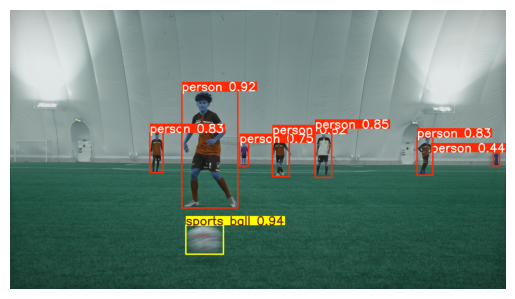

Ball box size: width=290.9783935546875, height=225.650390625


Confidence of finding ball is : 0.9403582811355591

YOLO detection used


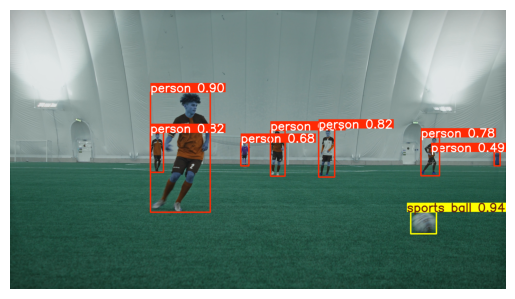

Ball box size: width=198.73388671875, height=170.228759765625


Confidence of finding ball is : 0.9445874094963074



YOLO failed or low confidence — falling back to HSV detection
HSV also failed to detect the ball
Both YOLO and HSV failed to detect the ball



YOLO failed or low confidence — falling back to HSV detection
HSV also failed to detect the ball
Both YOLO and HSV failed to detect the ball

YOLO detection used


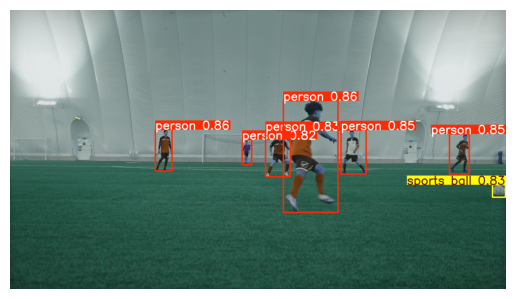

Ball box size: width=100.03125, height=96.671630859375


Confidence of finding ball is : 0.832416296005249

YOLO detection used


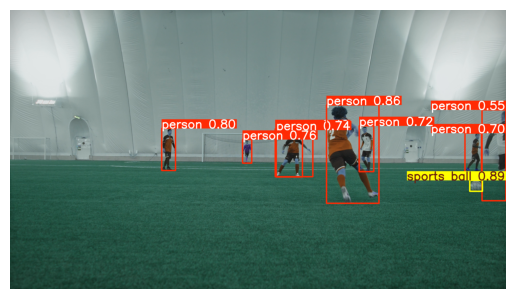

Ball box size: width=98.4814453125, height=84.1556396484375


Confidence of finding ball is : 0.889009952545166

YOLO detection used


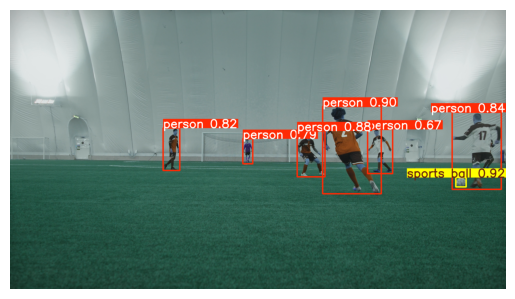

Ball box size: width=79.801025390625, height=72.4315185546875


Confidence of finding ball is : 0.9243007302284241



YOLO failed or low confidence — falling back to HSV detection
HSV also failed to detect the ball
Both YOLO and HSV failed to detect the ball



YOLO failed or low confidence — falling back to HSV detection
HSV also failed to detect the ball
Both YOLO and HSV failed to detect the ball

YOLO detection used


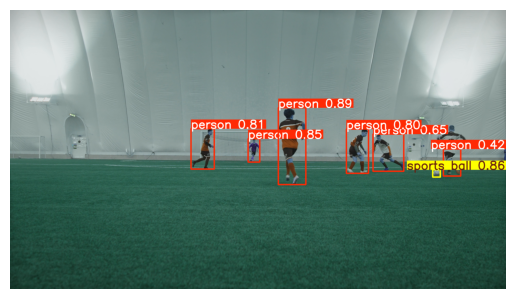

Ball box size: width=58.165283203125, height=56.481201171875


Confidence of finding ball is : 0.8622209429740906



YOLO failed or low confidence — falling back to HSV detection
HSV also failed to detect the ball
Both YOLO and HSV failed to detect the ball



YOLO failed or low confidence — falling back to HSV detection
HSV also failed to detect the ball
Both YOLO and HSV failed to detect the ball



YOLO failed or low confidence — falling back to HSV detection
HSV also failed to detect the ball
Both YOLO and HSV failed to detect the ball



YOLO failed or low confidence — falling back to HSV detection
HSV also failed to detect the ball
Both YOLO and HSV failed to detect the ball



YOLO failed or low confidence — falling back to HSV detection
HSV also failed to detect the ball
Both YOLO and HSV failed to detect the ball



YOLO failed or low confidence — falling back to HSV detection
HSV also failed to detect the ball
Both YOLO and HSV failed to detect the ball



YOLO failed or low 

In [17]:
centroid_history =[]
for frame in saved_frame :
  result = detect_ball_hybrid(frame)
  centroid_history.append(result)

In [19]:
print(centroid_history)
df = pd.DataFrame(centroid_history, columns=['x', 'y'])
print(df)

[(nan, nan), (nan, nan), (nan, nan), (nan, nan), (nan, nan), (nan, nan), (nan, nan), (1506.662109375, 1777.89599609375), (3202.347900390625, 1647.324462890625), (nan, nan), (nan, nan), (3785.332763671875, 1400.7430419921875), (3608.7080078125, 1360.932373046875), (3491.212890625, 1333.033203125), (nan, nan), (nan, nan), (3302.00830078125, 1265.2178955078125), (nan, nan), (nan, nan), (nan, nan), (nan, nan), (nan, nan), (nan, nan), (nan, nan), (nan, nan), (nan, nan), (nan, nan), (nan, nan), (nan, nan), (nan, nan), (nan, nan), (nan, nan), (nan, nan), (nan, nan), (nan, nan), (nan, nan), (nan, nan), (nan, nan)]
              x            y
0           NaN          NaN
1           NaN          NaN
2           NaN          NaN
3           NaN          NaN
4           NaN          NaN
5           NaN          NaN
6           NaN          NaN
7   1506.662109  1777.895996
8   3202.347900  1647.324463
9           NaN          NaN
10          NaN          NaN
11  3785.332764  1400.743042
12  3608.

In [20]:
df_interp = df.interpolate()
print(df_interp)

              x            y
0           NaN          NaN
1           NaN          NaN
2           NaN          NaN
3           NaN          NaN
4           NaN          NaN
5           NaN          NaN
6           NaN          NaN
7   1506.662109  1777.895996
8   3202.347900  1647.324463
9   3396.676188  1565.130656
10  3591.004476  1482.936849
11  3785.332764  1400.743042
12  3608.708008  1360.932373
13  3491.212891  1333.033203
14  3428.144694  1310.428101
15  3365.076497  1287.822998
16  3302.008301  1265.217896
17  3302.008301  1265.217896
18  3302.008301  1265.217896
19  3302.008301  1265.217896
20  3302.008301  1265.217896
21  3302.008301  1265.217896
22  3302.008301  1265.217896
23  3302.008301  1265.217896
24  3302.008301  1265.217896
25  3302.008301  1265.217896
26  3302.008301  1265.217896
27  3302.008301  1265.217896
28  3302.008301  1265.217896
29  3302.008301  1265.217896
30  3302.008301  1265.217896
31  3302.008301  1265.217896
32  3302.008301  1265.217896
33  3302.00830

In [21]:
df_interp = df.interpolate(limit_area='inside')
print(df_interp)

              x            y
0           NaN          NaN
1           NaN          NaN
2           NaN          NaN
3           NaN          NaN
4           NaN          NaN
5           NaN          NaN
6           NaN          NaN
7   1506.662109  1777.895996
8   3202.347900  1647.324463
9   3396.676188  1565.130656
10  3591.004476  1482.936849
11  3785.332764  1400.743042
12  3608.708008  1360.932373
13  3491.212891  1333.033203
14  3428.144694  1310.428101
15  3365.076497  1287.822998
16  3302.008301  1265.217896
17          NaN          NaN
18          NaN          NaN
19          NaN          NaN
20          NaN          NaN
21          NaN          NaN
22          NaN          NaN
23          NaN          NaN
24          NaN          NaN
25          NaN          NaN
26          NaN          NaN
27          NaN          NaN
28          NaN          NaN
29          NaN          NaN
30          NaN          NaN
31          NaN          NaN
32          NaN          NaN
33          Na

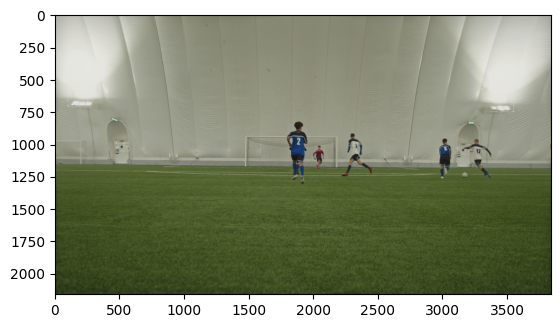

In [26]:
plt.imshow(cv2.cvtColor(saved_frame[17], cv2.COLOR_BGR2RGB))
plt.imshow(cv2.cvtColor(saved_frame[18], cv2.COLOR_BGR2RGB))
plt.imshow(cv2.cvtColor(saved_frame[19], cv2.COLOR_BGR2RGB))
plt.show()

In [ ]:
# **Day 14 Conclusion:**

# Fixed inconsistent NaN/None return types across detection functions so every
# frame returns `(x, y)`. Learned `interpolate(limit_area='inside')` fills only
# real gaps (between two known points) and correctly leaves leading/trailing
#  missing frames untouched — plain `.interpolate()` fakes trailing data by
#   freezing the last value. Confirmed via visual inspection that long gaps (
#   17-37) aren't a bug — the ball is real but too small/distant/low-contrast
#   o detect, a genuine CV limitation, not something interpolation should paper over.